In [3]:
import pandas as pd
df = pd.read_csv("../data/raw/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [6]:
df.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [7]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [8]:
from src.data_preprocessing import clean_text

sample = df['review'].iloc[0]
print("Original Text:\n")
print(sample)

print("\n" + "="*80 + "\n")

print("Cleaned Text:\n")
print(clean_text(sample))

Original Text:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show i

In [9]:
df['clean_review'] = df['review'].apply(clean_text)

In [10]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [11]:
df.to_csv("../data/processed/cleaned_imdb.csv", index=False)

In [12]:
from src.feature_engineering import create_tfidf_vectorizer, fit_transform_tfidf, transform_tfidf


In [13]:
vectorizer = create_tfidf_vectorizer()
X = fit_transform_tfidf(vectorizer, df['clean_review'])
X.shape

(50000, 10000)

Training the Model on Logistic Regression

In [14]:
#step 1: preparing the target variable
y = df['sentiment']

#In the dataset we have the sentiment column labelled as postive or negative
#but ml models can only understand number so change it to numeric labels
y = y.map({'positive': 1, 'negative': 0})

In [15]:
#step 2: splitting the data into training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42, stratify=y
)

In [16]:
#step 3: implementation on logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
#step 4: predictions
y_pred = model.predict(X_test)

In [18]:
#step 5: Evaluation
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("\nClassification Report: \n")
print(classification_report(y_test, y_pred))

Accuracy:  0.8936

Classification Report: 

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5000
           1       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



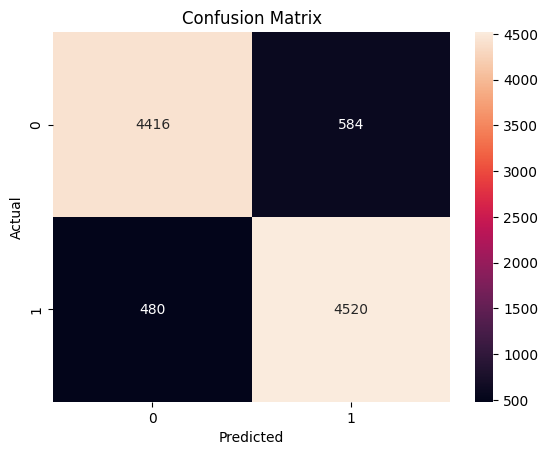

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

con_mat = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(con_mat, annot = True, fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Although our model got 89% accuracy with logistic regression model, it is important to do error analysis.. so that we get to know that what are the reviews that are wrongly identifies.
Maybe the model might wrongly predicted the reviews which were sarcastic or mixed sentiments or long nuanced.
Lets find where does the model fail!!

In [20]:
#extracting misclassified reviews
import numpy as np
misclassified = np.where(y_test != y_pred)[0]
print("Number of misclassified review samples are : ", len(misclassified))

Number of misclassified review samples are :  1064


In [21]:
for i in misclassified[:5]:
    print("Actual: ",y_test.iloc[i])
    print("Predicted: ",y_pred[i])
    print("Review: ",df['review'].iloc[X_test.indices[i]])
    print("-"*80)

Actual:  0
Predicted:  1
Review:  This is a extremely well-made film. The acting, script and camera-work are all first-rate. The music is good, too, though it is mostly early in the film, when things are still relatively cheery. There are no really superstars in the cast, though several faces will be familiar. The entire cast does an excellent job with the script.<br /><br />But it is hard to watch, because there is no good end to a situation like the one presented. It is now fashionable to blame the British for setting Hindus and Muslims against each other, and then cruelly separating them into two countries. There is some merit in this view, but it's also true that no one forced Hindus and Muslims in the region to mistreat each other as they did around the time of partition. It seems more likely that the British simply saw the tensions between the religions and were clever enough to exploit them to their own ends.<br /><br />The result is that there is much cruelty and inhumanity in 

In [22]:
import joblib

joblib.dump(model, "../models/logistic_regression.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

In [23]:
test_sentence = "I want to watch it again and again!"
cleaned = clean_text(test_sentence)
print(cleaned)

want watch


In [24]:
test = "The Movie has an amazing story and outstanding actors"

In [25]:
model.predict_proba(transform_tfidf(vectorizer, [clean_text(test)]))

array([[0.02047949, 0.97952051]])

Implementing Naive Bayes

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report 

In [27]:
# Initializing naive bayes model
nb_model = MultinomialNB()

# Training
nb_model.fit(X_train, y_train)

# Predicting
y_pred_nb = nb_model.predict(X_test)

#Evaluation
print("Naive Bayes Accuracy: ", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy:  0.865

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      5000
           1       0.85      0.88      0.87      5000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



Implementing SVM Model

In [28]:
from sklearn.svm import LinearSVC

# Initializing SVM
svm_model = LinearSVC()

# Training
svm_model.fit(X_train, y_train)

#Predicting
y_pred_svm = svm_model.predict(X_test)

# Evaluation
print("SVM Accuracy: ", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy:  0.8868

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.89      5000
           1       0.88      0.89      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [29]:
import joblib

# saving Naive Bayes
joblib.dump(nb_model, "../models/naive_bayes.pkl")

# saving SVM
joblib.dump(svm_model, "../models/svm.pkl")

['../models/svm.pkl']